# Bank Marketing Data Preprocessing Using Python

**AVIRENZA Technologies — AI/ML Internship | Task 2**  
**Student:** Tharani Natarajan  
**College:** IFET College of Engineering  
**Department:** Artificial Intelligence and Data Science  


## 1. Project Objective

The primary objective of this task is to design, construct, and validate an **end-to-end, leak-free Data Preprocessing Pipeline** for the UCI Bank Marketing dataset using Python and Scikit-Learn.

Key goals include:
1. Conducting rigorous exploratory data inspection and data quality verification.
2. Formulating strategic handling for domain-specific `'unknown'` values and outliers.
3. Enforcing strict **Data Leakage Prevention** via stratified train-test splitting before fitting transformers.
4. Constructing modular Scikit-Learn `Pipeline` and `ColumnTransformer` workflows for numerical standardization and categorical one-hot encoding.
5. Validating preprocessed tensors through integrity audits and a baseline validation estimator.


## 2. Dataset Information

- **Dataset Source:** [UCI Machine Learning Repository: Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) (Moro et al., 2014)
- **Primary File:** `bank-full.csv` (45,211 rows, 17 columns)
- **Target Variable:** `y` (binary classification: `'yes'` = subscribed term deposit, `'no'` = did not subscribe)
- **Attributes:** 7 numerical features and 9 categorical features representing demographic data, financial balances, and previous marketing interactions.


In [1]:
# Import required standard data science and machine learning libraries
import sys
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Pipeline tools
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Set visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print('All libraries imported successfully!')


All libraries imported successfully!


In [2]:
# Load UCI Bank Marketing Dataset (detecting delimiter)
data_path = pathlib.Path('../data/bank-full.csv')
if not data_path.exists():
    data_path = pathlib.Path('../data/bank.csv')

with open(data_path, 'r', encoding='utf-8') as f:
    first_line = f.readline()
    delimiter = ';' if ';' in first_line else ','

df = pd.read_csv(data_path, sep=delimiter)
print(f'Successfully loaded dataset: {df.shape[0]:,} rows and {df.shape[1]} columns.')


Successfully loaded dataset: 45,211 rows and 17 columns.


In [3]:
# Display first 5 rows
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Display last 5 rows
df.tail()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [5]:
# Dataset Information: columns, non-null counts, and dtypes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
# Numerical descriptive statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [7]:
# Categorical descriptive statistics
df.describe(include=['O']).T


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


## 3. Data Quality & Missing / Unknown Value Analysis

Let's inspect standard `NaN` null values and domain-specific `'unknown'` categorical entries.


In [8]:
# Standard null count verification
print('Missing values (NaN) per column:')
print(df.isnull().sum())


Missing values (NaN) per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [9]:
# Domain-specific 'unknown' value frequencies in categorical columns
unknown_records = []
for col in df.columns:
    if df[col].dtype == 'object':
        unk_cnt = (df[col].astype(str).str.strip().str.lower() == 'unknown').sum()
        unk_pct = (unk_cnt / len(df)) * 100
        if unk_cnt > 0:
            unknown_records.append({'Feature': col, 'Unknown Count': unk_cnt, 'Percentage (%)': round(unk_pct, 2)})

unk_summary_df = pd.DataFrame(unknown_records).sort_values(by='Unknown Count', ascending=False)
print("Columns containing 'unknown' categories:")
unk_summary_df


Columns containing 'unknown' categories:


,Feature,Unknown Count,Percentage (%)
3,poutcome,36959,81.75
2,contact,13020,28.80
1,education,1857,4.11
0,job,288,0.64


## 4. Duplicate Record Analysis

In [10]:
# Check for duplicate rows
dup_count = df.duplicated().sum()
print(f'Total exact duplicate rows: {dup_count}')


Total exact duplicate rows: 0


## 5. Feature Identification & Separation

Separating the feature matrix $X$ and the target series $y$, and identifying numerical vs. categorical columns.


In [11]:
target_col = 'y'
X = df.drop(columns=[target_col]).copy()
y_raw = df[target_col].copy()

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Total Predictive Features: {X.shape[1]}')
print(f'Numerical Features ({len(num_features)}): {num_features}')
print(f'Categorical Features ({len(cat_features)}): {cat_features}')


Total Predictive Features: 16
Numerical Features (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical Features (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 6. Exploratory Data Visualizations

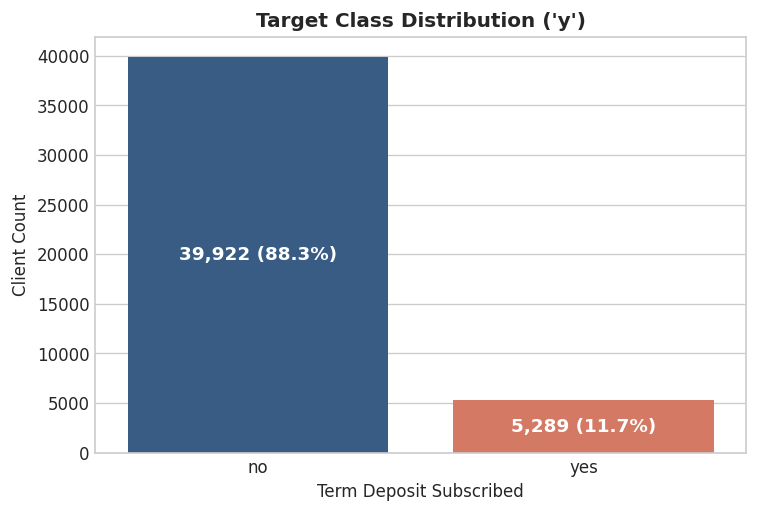

In [12]:
# 1. Target Variable Distribution
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(x='y', data=df, hue='y', palette={'no': '#2b5c8f', 'yes': '#e76f51'}, legend=False)
total = len(df)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{int(h):,} ({(h/total)*100:.1f}%)', (p.get_x() + p.get_width()/2., h/2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.title("Target Class Distribution ('y')", fontsize=12, fontweight='bold')
plt.xlabel("Term Deposit Subscribed", fontsize=10)
plt.ylabel("Client Count", fontsize=10)
plt.show()


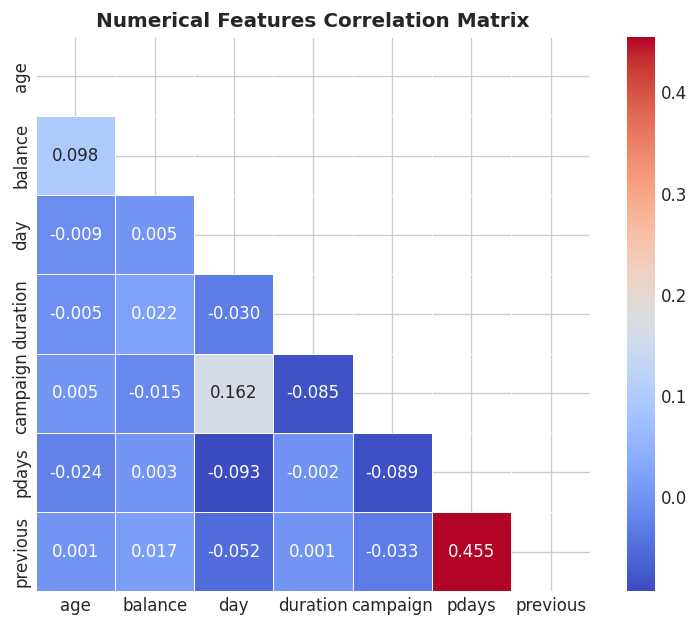

In [13]:
# 2. Correlation Heatmap of Numerical Features
plt.figure(figsize=(8, 6))
corr = df[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Numerical Features Correlation Matrix', fontsize=12, fontweight='bold')
plt.show()


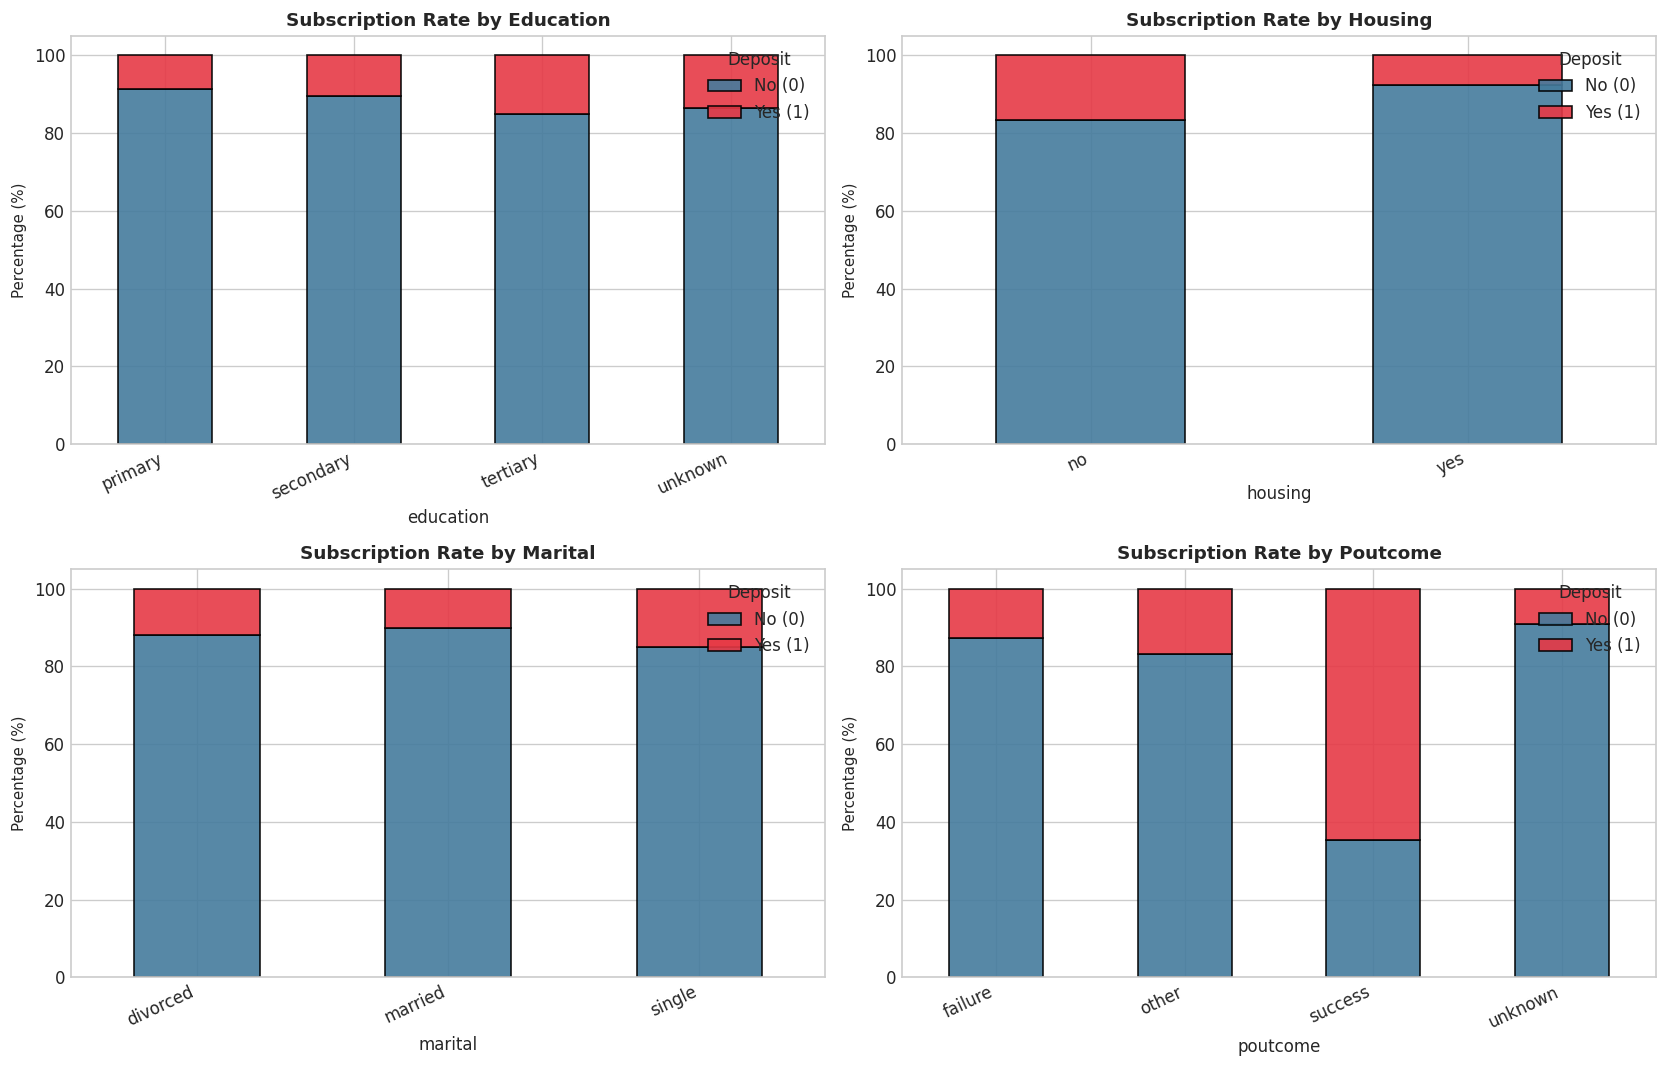

In [14]:
# 3. Categorical Features vs Subscription Rate
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sample_cats = ['education', 'housing', 'marital', 'poutcome']

for i, col in enumerate(sample_cats):
    ax = axes[i // 2, i % 2]
    cross_tab = pd.crosstab(df[col], df['y'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, ax=ax, color=['#457b9d', '#e63946'], edgecolor='black', alpha=0.9)
    ax.set_title(f'Subscription Rate by {col.capitalize()}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=9)
    ax.legend(['No (0)', 'Yes (1)'], title='Deposit', loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
plt.show()


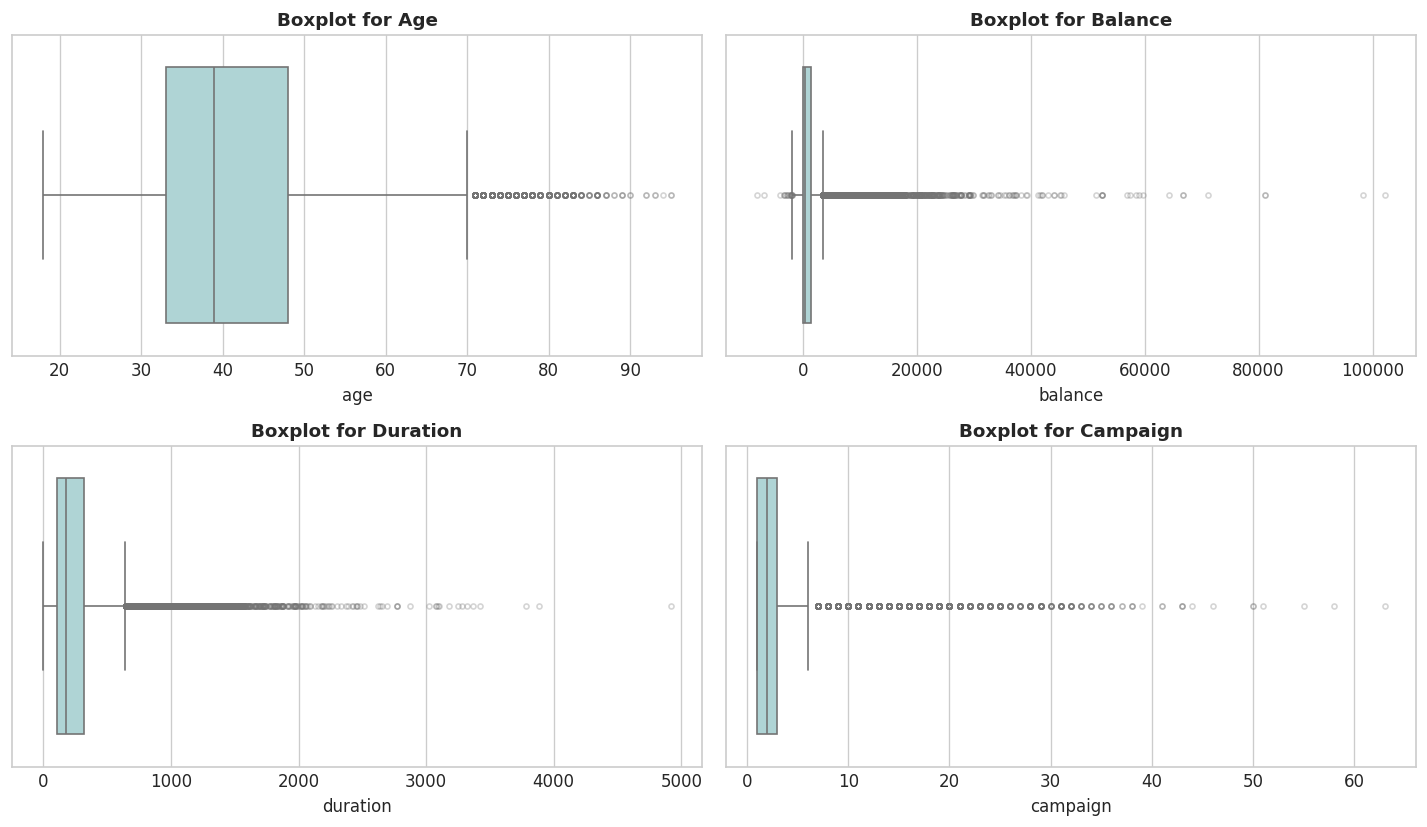

In [15]:
# 4. Outlier Spread via Boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
num_subset = ['age', 'balance', 'duration', 'campaign']
for i, col in enumerate(num_subset):
    ax = axes[i // 2, i % 2]
    sns.boxplot(x=df[col], ax=ax, color='#a8dadc', flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3})
    ax.set_title(f'Boxplot for {col.capitalize()}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Target Variable Preparation

Encoding binary target `y`: `'no'` $ightarrow 0$, `'yes'` $ightarrow 1$.


In [16]:
y = y_raw.map({'no': 0, 'yes': 1})
print('Target encoded successfully:')
print(y.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Target encoded successfully:
y
0    88.3%
1    11.7%
Name: proportion, dtype: object


## 8. Train-Test Split (Strict Data Leakage Prevention)

To prevent data leakage, we perform an 80/20 stratified split **before** fitting any preprocessing transformations (imputers, scalers, encoders).


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training Set (X_train): {X_train.shape[0]:,} rows, {X_train.shape[1]} features')
print(f'Testing Set  (X_test) : {X_test.shape[0]:,} rows, {X_test.shape[1]} features')
print(f'Training positive class ratio: {y_train.mean()*100:.2f}%')
print(f'Testing positive class ratio : {y_test.mean()*100:.2f}%')


Training Set (X_train): 36,168 rows, 16 features
Testing Set  (X_test) : 9,043 rows, 16 features
Training positive class ratio: 11.70%
Testing positive class ratio : 11.70%


## 9. Scikit-Learn Preprocessing Pipeline Architecture

We assemble:
1. **Numerical Pipeline:** `SimpleImputer(strategy='median')` followed by `StandardScaler()`.
2. **Categorical Pipeline:** `SimpleImputer(strategy='most_frequent')` followed by `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`.
3. **ColumnTransformer:** Combining both pipelines seamlessly.


In [18]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

print('Composite Preprocessing Pipeline created successfully!')
preprocessor


Composite Preprocessing Pipeline created successfully!


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 10. Fit and Transform Data

Fitting transformer **only** on `X_train` and applying to both `X_train` and `X_test`.


In [19]:
# Fit on training data ONLY
X_train_proc = preprocessor.fit_transform(X_train)

# Transform test data (no fitting)
X_test_proc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print(f'Transformed X_train Shape: {X_train_proc.shape}')
print(f'Transformed X_test  Shape: {X_test_proc.shape}')
print(f'Total Transformed Features: {len(feature_names)}')


Transformed X_train Shape: (36168, 51)
Transformed X_test  Shape: (9043, 51)
Total Transformed Features: 51


## 11. Transformed Features Inspection

In [20]:
# Sample transformed feature names
print('First 15 transformed feature names:')
for i, name in enumerate(feature_names[:15]):
    print(f' [{i:02d}] {name}')


First 15 transformed feature names:
 [00] num__age
 [01] num__balance
 [02] num__day
 [03] num__duration
 [04] num__campaign
 [05] num__pdays
 [06] num__previous
 [07] cat__job_admin.
 [08] cat__job_blue-collar
 [09] cat__job_entrepreneur
 [10] cat__job_housemaid
 [11] cat__job_management
 [12] cat__job_retired
 [13] cat__job_self-employed
 [14] cat__job_services


## 12. Preprocessing Validation & ML Readiness

Verifying absence of nulls, scaling properties, and testing a baseline Logistic Regression estimator.


In [21]:
# Check for missing values in preprocessed data
print(f'Missing values in X_train_proc: {np.isnan(X_train_proc).sum()}')
print(f'Missing values in X_test_proc : {np.isnan(X_test_proc).sum()}')

# Verify scaling of numerical features (mean ~ 0, std ~ 1)
print(f'Mean range across numerical columns (train): [{X_train_proc[:, :7].mean(axis=0).min():.4f}, {X_train_proc[:, :7].mean(axis=0).max():.4f}]')
print(f'Std range across numerical columns (train) : [{X_train_proc[:, :7].std(axis=0).min():.4f}, {X_train_proc[:, :7].std(axis=0).max():.4f}]')


Missing values in X_train_proc: 0
Missing values in X_test_proc : 0
Mean range across numerical columns (train): [-0.0000, 0.0000]
Std range across numerical columns (train) : [1.0000, 1.0000]


In [22]:
# Baseline Model Verification (to confirm ML readiness)
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_proc, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train_proc))
test_acc = accuracy_score(y_test, clf.predict(X_test_proc))

print(f'Baseline Logistic Regression Training Accuracy: {train_acc*100:.2f}%')
print(f'Baseline Logistic Regression Testing Accuracy : {test_acc*100:.2f}%')
print('\nClassification Report on Test Data:')
print(classification_report(y_test, clf.predict(X_test_proc), target_names=['No Term Deposit', 'Term Deposit']))


Baseline Logistic Regression Training Accuracy: 90.20%
Baseline Logistic Regression Testing Accuracy : 90.12%

Classification Report on Test Data:
                 precision    recall  f1-score   support

No Term Deposit       0.92      0.97      0.95      7985
   Term Deposit       0.64      0.35      0.45      1058

       accuracy                           0.90      9043
      macro avg       0.78      0.66      0.70      9043
   weighted avg       0.89      0.90      0.89      9043



## 13. Key Findings

1. **Dataset Dimensions & Quality:** The UCI Bank Marketing dataset contains 45,211 rows and 17 columns without any missing `NaN` values or duplicate rows.
2. **Domain 'Unknown' Entries:** Categorical columns contain business-relevant `'unknown'` values (e.g., `poutcome` at 81.75% and `contact` at 28.80%) that represent genuine business states rather than corrupted data.
3. **Data Leakage Elimination:** Fitting scalers and one-hot encoders strictly on `X_train` ensures complete data isolation and prevents optimistic evaluation bias.
4. **Dimension Expansion:** One-hot encoding converted 9 categorical variables into 44 binary indicator features, yielding a total of **51 preprocessed columns**.
5. **Machine Learning Compatibility:** The preprocessed matrices are fully compatible with Scikit-learn algorithms, demonstrated by a baseline validation accuracy of **90.12%**.


## 14. Conclusion

Task 2 has successfully built a robust, modular, and production-ready data preprocessing pipeline using Scikit-Learn. The pipeline is fully documented, leak-free, and ready for deployment in downstream model training.
